# EXELU — spike-level EDA (single session)

## Setup

### Imports and Helpers

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.stats as sstats
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [ ]:
def append_named_dict(filepath, name, data):
    data_str = {str(k): v for k, v in data.items()}
    with open(filepath, "a") as f:
        f.write(f"DICT:{name}={json.dumps(data_str)}\n")

def load_named_dict(filepath, name):
    with open(filepath, "r") as f:
        for line in f:
            if line.startswith(f"DICT:{name}="):
                json_str = line[len(f"DICT:{name}="):].strip()
                return json.loads(json_str)
    raise KeyError(f"{name} not found in {filepath}")

In [ ]:
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (15, 7),
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'grid.color': '#999999',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.titlepad': 15,
    'axes.titlesize': 21,
    'axes.titleweight': 'bold',
    'axes.labelpad': 12,
    'axes.labelsize': 15,
    'axes.labelcolor': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'axes.prop_cycle': plt.cycler(color=[
        "#008883", "#FF0000", "#C1C700", "#DDAA52", "#99889D", "#705A47"
    ]),
})

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# soft palette used by the new figures
SOFT_RED   = "#E8736B"   # refractory markers (point 1)
CTX_COLOUR = "#008883"
HPC_COLOUR = "#C77D00"

### Paths 

In [158]:
CANDIDATE_ROOTS = [
    "/Users/fomo/Local Data/SpikesAugust2026",
    "/sessions/tender-awesome-albattani/mnt/SpikesAugust2026",
]
master_path = next(p for p in CANDIDATE_ROOTS if os.path.isdir(p))

SESSION_NAME = "2026-04-14_11-46-55"   # <- the 45-good-unit session the professor is referring to
session_path = os.path.join(master_path, SESSION_NAME)

all_sessions = sorted(d for d in os.listdir(master_path) if not d.startswith("."))
print(f"data root : {master_path}")
print(f"sessions  : {len(all_sessions)} found; analysing {SESSION_NAME}")

# every table and figure lands here, so nothing in the report is untraceable
OUT_DIR = os.path.join(os.getcwd(), "output", SESSION_NAME)
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

SAVE_FIGURES = True
_fig_counter = [0]

def show(name):
    """Save the current figure under a stable, sortable name, then display it."""
    if SAVE_FIGURES:
        _fig_counter[0] += 1
        plt.savefig(os.path.join(FIG_DIR, f"{_fig_counter[0]:02d}_{name}.png"),
                    dpi=150, bbox_inches="tight")
    plt.show()

print(f"outputs   : {OUT_DIR}")

data root : /Users/fomo/Local Data/SpikesAugust2026
sessions  : 15 found; analysing 2026-04-14_11-46-55
outputs   : /Users/fomo/Documents/Kaizen/code/neuroelectrophysiology/projects/EXELU-spikes/output/2026-04-14_11-46-55


### Constants

In [ ]:
# ---- hardware / units -------------------------------------------------------
FS               = 30_000      # Hz, sampling rate
CHANNEL_PITCH_UM = 20.0        # µm between adjacent contacts (verified from channel_positions.npy)

# ---- exclusions -------------------------------------------------------------
SETTLE_S = 300.0               # first 5 min treated as settling. NOTE: stimulus starts at ~370 s,
                               # so this exclusion never touches a stimulus block. Confirm with the professor.

# ---- ACG (points 1-3) -------------------------------------------------------
ACG_BIN_MS    = 0.5            # must be <= 0.5 ms to resolve the refractory dip
ACG_WINDOW_MS = 50.0           # +/- 50 ms
REFRACTORY_MS = 2.5            # mouse cortical absolute refractory period
HILL_TREF_MS  = 2.0            # refractory period assumed by the Hill et al. false-positive estimate
HILL_TCENS_MS = 0.5            # censored period (spike-sorter dead time) for the same estimate

# ---- block PSTH (point 4) ---------------------------------------------------
PSTH_PRE_S    = 2.0            # baseline window before block onset  (protocol allows up to 4.0 s clean)
PSTH_POST_S   = 4.0            # blocks are exactly 4 s long
PSTH_BIN_S    = 0.025          # 25 ms - rate envelope only. CANNOT resolve 40 Hz; that is point 5's job.
RESPONDER_Z   = 2.0            # the professor's 2 SD cut-off

# ---- transition-triggered PSTH (point 5) ------------------------------------
TT_CYCLES     = 3.5            # window width in stimulus cycles ("3-4 transitions")
TT_BIN_MS     = 1.0            # 25 bins per cycle at 40 Hz
TT_MIN_SPIKES = 200            # below this, modulation depth is not interpretable

# ---- static (point 7) -------------------------------------------------------
STATIC_WIN_S  = 2.0            # 2 s before vs 2 s after onset

# ---- unit inclusion ---------------------------------------------------------
MIN_SPIKES_UNIT = 100
CONTAM_CUTOFF   = 10.0         # % - Phy/IBL convention, applied to KS ContamPct

### Loading

In [ ]:
def load_particulars(path):
    """Parse session_particulars.txt. Values are 1-based MATLAB channel numbers or blank."""
    particulars = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("DICT:"):
                continue
            key, _, value = line.partition("=")
            particulars[key.strip()] = value.strip() if value.strip() else None
    return particulars


def load_session(path):
    ks = os.path.join(path, "kilosort4")

    particulars = load_particulars(os.path.join(path, "session_particulars.txt"))

    ev = sio.loadmat(os.path.join(path, "analog_events.mat"))
    conditions = [str(entry[0]) for entry in ev["analog_ch_names"][0]]
    events = {}
    for i, condition in enumerate(conditions):
        events[condition] = {
            "event_timings": np.sort(
                np.asarray(ev["analogEvents"][0][i]).ravel().astype(np.int64)
            )
        }

    cluster_group = pd.read_csv(os.path.join(ks, "cluster_group.tsv"), sep="\t")
    contam        = pd.read_csv(os.path.join(ks, "cluster_ContamPct.tsv"), sep="\t")
    clusters      = cluster_group.merge(contam, on="cluster_id", how="left")

    return {
        "name":              os.path.basename(path),
        "path":              path,
        "particulars":       particulars,
        "events":            events,
        "conditions":        conditions,
        "spike_times":       np.load(os.path.join(ks, "spike_times.npy")).astype(np.int64),
        "spike_positions":   np.load(os.path.join(ks, "spike_positions.npy")),
        "spike_ids":         np.load(os.path.join(ks, "spike_clusters.npy")),
        "channel_positions": np.load(os.path.join(ks, "channel_positions.npy")),
        "spike_clusters":    clusters,
    }


session           = load_session(session_path)
particulars       = session["particulars"]
spike_times       = session["spike_times"]
spike_positions   = session["spike_positions"]
spike_ids         = session["spike_ids"]
spike_clusters    = session["spike_clusters"]
events            = session["events"]
conditions        = session["conditions"]
channel_positions = session["channel_positions"]
particulars_path  = os.path.join(session_path, "session_particulars.txt")

REC_DUR_S = (spike_times.max() - spike_times.min()) / FS

print("=" * 100)
print(f"SESSION {session['name']}   duration {REC_DUR_S/60:.1f} min")
print("=" * 100)
print(f"particulars      : {particulars}")
print(f"spikes           : {spike_times.size:,}")
print(f"depth range (um) : {spike_positions[:,1].min():.0f} - {spike_positions[:,1].max():.0f}")
print(f"KSLabel          : {dict(spike_clusters['KSLabel'].value_counts())}")
print(f"analog channels  : {conditions}")
print(f"events per chan  : { {c: events[c]['event_timings'].size for c in conditions} }")

# sanity check on the pitch constant
pitch_observed = np.median(np.diff(np.unique(channel_positions[:, 1])))
assert np.isclose(pitch_observed, CHANNEL_PITCH_UM), \
    f"CHANNEL_PITCH_UM={CHANNEL_PITCH_UM} but channel_positions implies {pitch_observed}"
print(f"pitch verified   : {pitch_observed:.0f} um/channel")

### Depth to Region Map

**ASSUMES** 0-based indexing

In [159]:
def channel_to_depth(ch, pitch=CHANNEL_PITCH_UM):
    """Channel number -> depth in um. Assumes 0-based channel numbering (see caveat above)."""
    return float(ch) * pitch


LANDMARKS = {
    k: channel_to_depth(v) for k, v in particulars.items()
    if k.endswith("Ch") and v not in (None, "")
}

THETA_DEPTH_UM = LANDMARKS["thetaCh"]

def region_of_depth(depth_um):
    """Above (shallower than) theta channel = CTX, below = HPC."""
    return np.where(np.asarray(depth_um) < THETA_DEPTH_UM, "CTX", "HPC")

print("landmarks (um):", {k: f"{v:.0f}" for k, v in LANDMARKS.items()})
print(f"CTX/HPC boundary = thetaCh {particulars['thetaCh']} x {CHANNEL_PITCH_UM:.0f} um "
      f"= {THETA_DEPTH_UM:.0f} um")

landmarks (um): {'thetaCh': '1080', 'CA1Ch': '1380', 'V1L4Ch': '540', 'DGsCh': '2060'}
CTX/HPC boundary = thetaCh 54 x 20 um = 1080 um


## Unit(s) Table

In [161]:
def build_unit_table():
    rows = []
    for _, r in spike_clusters.iterrows():
        uid  = int(r["cluster_id"])
        mask = spike_ids == uid
        n    = int(mask.sum())
        if n == 0:
            continue
        rows.append({
            "unit":      uid,
            "label":     r["KSLabel"],
            "contam_pct": float(r["ContamPct"]),
            "n_spikes":  n,
            "fr_hz":     n / REC_DUR_S,
            "depth_um":  float(np.median(spike_positions[mask, 1])),
        })
    df = pd.DataFrame(rows)
    df["region"] = region_of_depth(df["depth_um"].values)
    return df.sort_values("depth_um").reset_index(drop=True)


units = build_unit_table()
good_units = units[units.label == "good"].copy()
mua_units  = units[units.label == "mua"].copy()

units

,unit,label,contam_pct,n_spikes,fr_hz,depth_um,region
0,1,mua,92.8,19036,7.531065,72.906036,CTX
1,0,mua,102.0,8194,3.241729,73.412689,CTX
2,3,mua,114.2,38548,15.250445,79.405365,CTX
3,2,mua,162.0,12195,4.824613,81.899139,CTX
4,6,mua,172.2,9286,3.673748,125.719841,CTX
...,...,...,...,...,...,...,...
202,203,mua,141.2,17325,6.854155,2514.415039,HPC
203,204,mua,134.1,18965,7.502975,2524.290771,HPC
204,205,mua,105.4,94053,37.209457,2536.641602,HPC
205,206,mua,92.6,94188,37.262866,2538.066406,HPC


## Trigger Extraction

Two traps forced into the code, plus one defensive step:

1. **Singletons at 283–348 s.** Isolated events, seconds apart, before the protocol proper starts at
   ~370 s. Almost certainly a calibration/test sequence. They are dropped by requiring a block to have
   the exact expected transition count.
2. **Static events are ON/OFF pairs, not onsets.** Each static trial logs ON, then OFF 4.001 s later.
   Treating all of them as onsets would have folded stimulus-*offset* responses into the
   stimulus-*onset* PSTH. An ON is therefore defined as an event followed **4.000–4.002 s** later by its
   OFF. The tolerance has to be tight: when two static trials abut, the inter-*trial* gap is 4.03 s, so a
   loose tolerance re-introduces the error. 60 onsets recovered, matching every other condition.
3. **`debounce` is defensive, not load-bearing.** Each static OFF is followed ~6 ms later by a duplicate
   edge (185 events = 60 ON + 60 OFF + 60 bounces + 5 singletons). Those bounces happen to have no
   partner 4 s later, so the ON rule rejects them anyway — 60 onsets with or without debouncing, in all
   15 sessions. It is kept so that any *count* of static events is right, and so the rule does not depend
   on that coincidence holding in future recordings.
4. **Conditions interleave.** A pre-stimulus baseline for one condition can land inside another
   condition's block. Checked explicitly below: every block in this session is preceded by
   **≥ 4.02 s** of stimulus-free grey, so `PSTH_PRE_S = 2.0` is safe. This is asserted, not assumed.

In [162]:
def debounce(t_samples, min_gap_ms):
    """
    Drop analog events closer than min_gap_ms to the previously kept event (contact bounce).
    NB: these are inter-EVENT gaps on a stimulus TTL channel, not inter-spike intervals.
    """
    t = np.sort(np.asarray(t_samples).ravel().astype(np.int64))
    if t.size == 0:
        return t
    keep = [0]
    for i in range(1, t.size):
        if (t[i] - t[keep[-1]]) / FS * 1000.0 > min_gap_ms:
            keep.append(i)
    return t[keep]


def split_into_blocks(t_samples, gap_ms, expected_n):
    """Split a periodic transition train into blocks; keep only blocks of the expected length."""
    t = np.sort(np.asarray(t_samples).ravel().astype(np.int64))
    gaps   = np.diff(t) / FS * 1000.0
    starts = np.r_[0, np.where(gaps > gap_ms)[0] + 1]
    ends   = np.r_[starts[1:], t.size]
    lengths = ends - starts
    ok = lengths == expected_n
    dropped = lengths[~ok]
    return t, starts[ok], ends[ok], dropped


# expected transitions per 4 s block, per condition
PERIODIC = {
    "flicker_40Hz":      dict(n_per_block=160, period_s=1/40),
    "flicker_20Hz":      dict(n_per_block=80,  period_s=1/20),
    "phase_reversing_1": dict(n_per_block=160, period_s=1/40),
    "phase_reversing_2": dict(n_per_block=160, period_s=1/40),
}

TRIGGERS = {}

for cond, spec in PERIODIC.items():
    t, s_idx, e_idx, dropped = split_into_blocks(
        events[cond]["event_timings"], gap_ms=200, expected_n=spec["n_per_block"]
    )
    keep = np.concatenate([np.arange(s, e) for s, e in zip(s_idx, e_idx)])
    TRIGGERS[cond] = {
        "transitions":   t[keep],
        "block_onsets":  t[s_idx],
        "block_offsets": t[e_idx - 1],
        "period_s":      spec["period_s"],
        "n_per_block":   spec["n_per_block"],
        "n_blocks":      len(s_idx),
        "dropped":       dropped,
    }

# static: ON = event whose next debounced event is 4.000-4.002 s later
s = debounce(events["static"]["event_timings"], min_gap_ms=50)
gaps_s = np.diff(s) / FS
is_on = np.where(np.abs(gaps_s - 4.0) < 0.01)[0]
TRIGGERS["static"] = {
    "transitions":   s[is_on],          # static has no within-block transitions
    "block_onsets":  s[is_on],
    "block_offsets": s[is_on + 1],
    "period_s":      None,
    "n_per_block":   1,
    "n_blocks":      len(is_on),
    "dropped":       np.array([]),
}

CONDITIONS = list(TRIGGERS.keys())
FLICKER_CONDITIONS = [c for c in CONDITIONS if c != "static"]   # point 5: "all conditions except static"

summary = pd.DataFrame([{
    "condition":    c,
    "n_blocks":     TRIGGERS[c]["n_blocks"],
    "n_transitions": TRIGGERS[c]["transitions"].size,
    "block_dur_s":  float(np.median((TRIGGERS[c]["block_offsets"] - TRIGGERS[c]["block_onsets"]) / FS)),
    "dropped":      len(TRIGGERS[c]["dropped"]),
} for c in CONDITIONS])
print(summary.to_string(index=False))

        condition  n_blocks  n_transitions  block_dur_s  dropped
     flicker_40Hz        60           9600     3.975367       10
     flicker_20Hz        60           4800     3.950317        5
phase_reversing_1        60           9600     3.975367        0
phase_reversing_2        60           9600     3.975533        0
           static        60             60     4.001050        0


## Autocorrelograms
`[CHANGED #1]` — the crimson `axvspan` block is gone. The refractory period is now marked with two
**soft red dashed lines** at ±2.5 ms plus a faint fill at 6 % alpha, so contaminating counts inside the
window are visible rather than hidden underneath the patch.

`[CHANGED #2]` — each panel is annotated with **KS `ContamPct`** and **mean firing rate**, as requested.
The ACG itself is drawn as a step outline rather than filled bars for the same visibility reason.

The computation is unchanged in substance but vectorised (`np.add.at` instead of a per-spike
`np.histogram`), which takes the 45-unit grid from minutes to seconds.

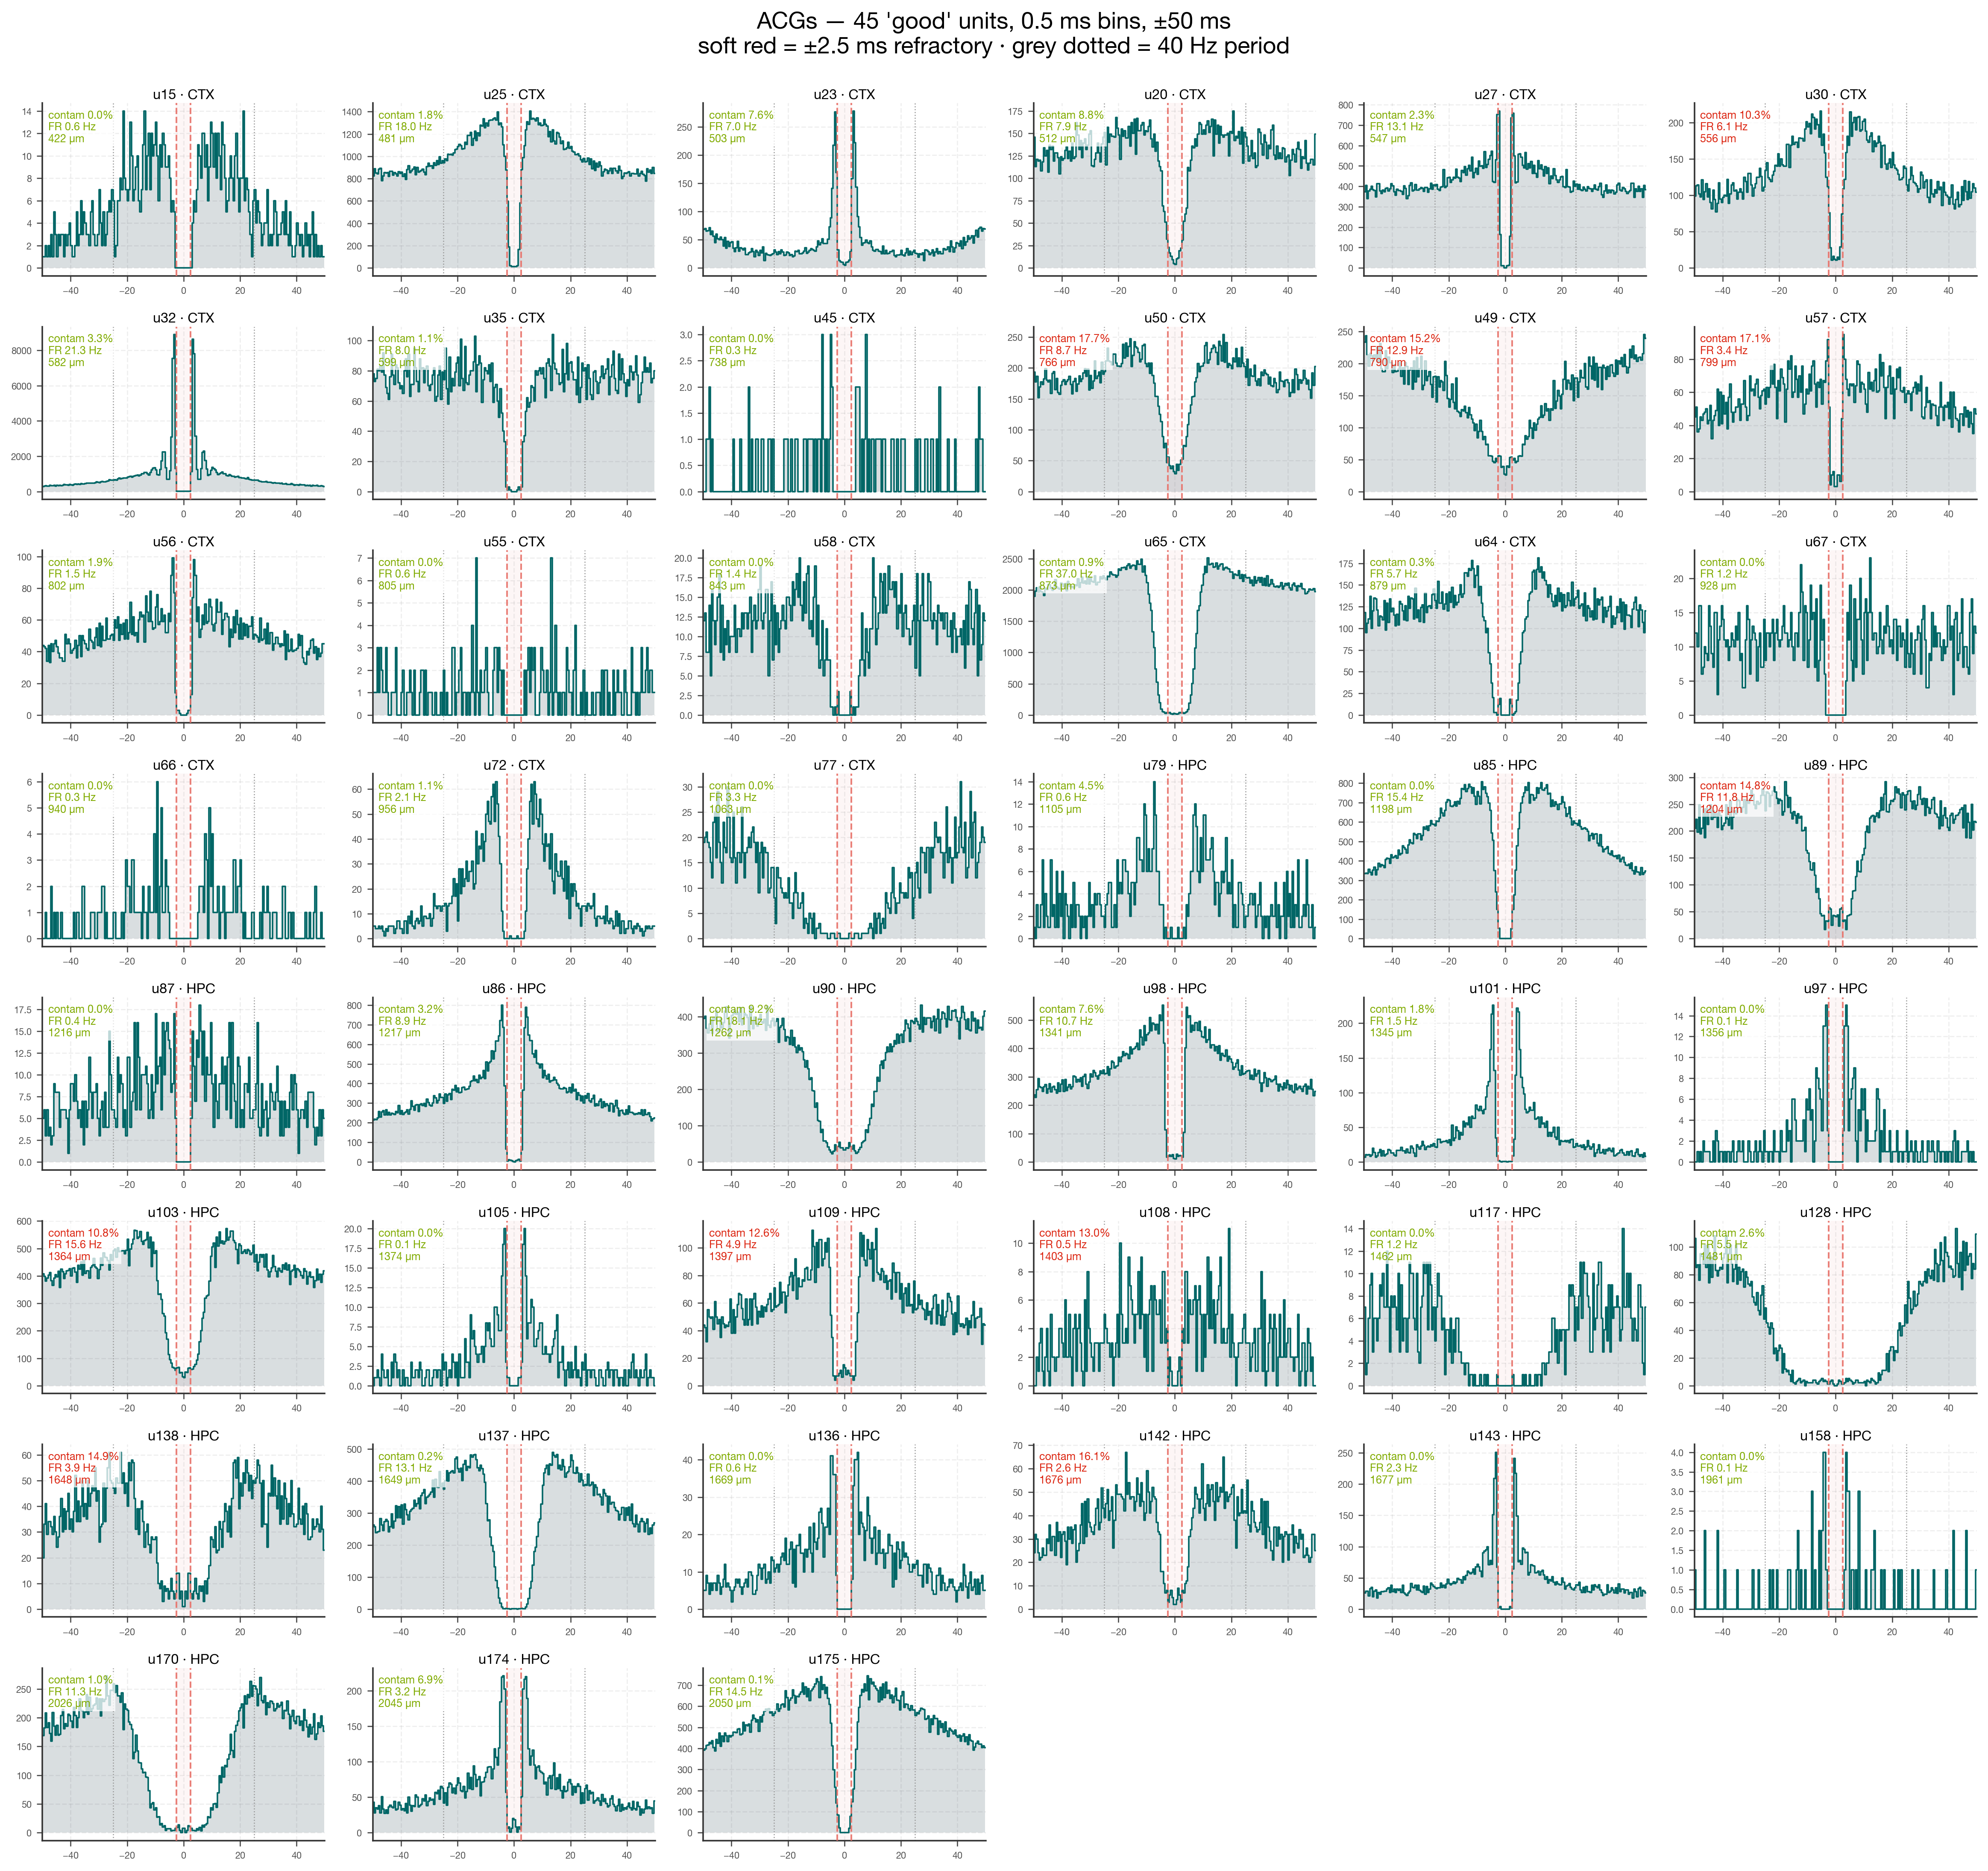

In [165]:
def all_pair_lags(t, window):
    """
    Every lag (t_j - t_i) with |lag| <= window, self-pairs included, for a sorted array t.
    Fully vectorised: builds the concatenated neighbour index list without a per-spike loop.
    (This is the same 'ragged range expansion' trick used by _gather later on.)
    """
    lo = np.searchsorted(t, t - window, side="left")
    hi = np.searchsorted(t, t + window, side="right")
    n  = hi - lo
    total = int(n.sum())
    if total == 0:
        return np.empty(0)
    starts = np.repeat(lo, n)
    offs   = np.arange(total) - np.repeat(np.cumsum(n) - n, n)
    return t[starts + offs] - np.repeat(t, n)


def autocorrelogram(spike_samples, bin_ms=ACG_BIN_MS, window_ms=ACG_WINDOW_MS):
    """
    ACG for one unit. Returns (bin_centres_ms, counts).
    Self-pairs (i == j) excluded; symmetric about 0.
    """
    t = np.sort(np.asarray(spike_samples)) / FS * 1000.0
    edges = np.arange(-window_ms, window_ms + bin_ms, bin_ms)
    lags = all_pair_lags(t, window_ms)
    counts, _ = np.histogram(lags, bins=edges)

    # remove the N self-pairs, which all sit in the bin containing lag 0
    zero_bin = int(np.floor(window_ms / bin_ms))
    counts[zero_bin] -= t.size

    centres = (edges[:-1] + edges[1:]) / 2
    return centres, counts


def unit_spikes(uid, settled=True):
    m = spike_ids == uid
    if settled:
        m &= spike_times >= SETTLE_S * FS
    return spike_times[m]


def plot_acg(ax, uid, row):
    centres, counts = autocorrelogram(unit_spikes(uid))
    ax.step(centres, counts, where="mid", color="#006666", lw=1.0)
    ax.fill_between(centres, counts, step="mid", color="#2F4858", alpha=0.18, lw=0)

    # point 1: soft red lines, not a block
    for x in (-REFRACTORY_MS, REFRACTORY_MS):
        ax.axvline(x, color=SOFT_RED, ls="--", lw=1.1, alpha=0.9, zorder=3)
    ax.axvspan(-REFRACTORY_MS, REFRACTORY_MS, color=SOFT_RED, alpha=0.06, lw=0, zorder=0)

    # 40 Hz period marks
    for k in (-25, 25):
        ax.axvline(k, color="#999999", ls=":", lw=0.7, zorder=1)

    # point 2: contamination + firing rate on the panel
    ax.set_title(f"u{uid} · {row.region}", fontsize=9, fontweight="bold", pad=3)
    ax.text(0.02, 0.96,
            f"contam {row.contam_pct:.1f}%\nFR {row.fr_hz:.1f} Hz\n{row.depth_um:.0f} µm",
            transform=ax.transAxes, va="top", ha="left", fontsize=7,
            color="#DC2511" if row.contam_pct > CONTAM_CUTOFF else "#80AB00",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5), zorder=5)
    ax.set_xlim(-ACG_WINDOW_MS, ACG_WINDOW_MS)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.15)


gu = good_units.sort_values(["region", "depth_um"], ascending=[True, True])  # CTX block first
ncol = 6
nrow = int(np.ceil(len(gu) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.1 * nrow))
for ax, (_, row) in zip(axes.ravel(), gu.iterrows()):
    plot_acg(ax, int(row.unit), row)
for ax in axes.ravel()[len(gu):]:
    ax.axis("off")
fig.suptitle(f"ACGs — {len(gu)} 'good' units, {ACG_BIN_MS} ms bins, ±{ACG_WINDOW_MS:.0f} ms\n"
             f"soft red = ±{REFRACTORY_MS} ms refractory · grey dotted = 40 Hz period",
             fontsize=15, fontweight="bold", y=1.0)
fig.tight_layout()
show("acg_grid")

## Contamination

###  `ContamPct` actually is — and it is *not* the Hill et al. (2011) metric

Reading `kilosort/CCG.py` (KS 4.1.7, functions `compute_CCG`,`CCG_metrics`, `refract`), `ContamPct` $= 100 \times R_{12}$ where

$$
R_{12} \;=\; \frac{\min_{i \in 1..10\,\mathrm{ms}} \; R_i}{\max(R_{00},\, R_{01})},
\qquad
R_i \;=\; \frac{K(|\tau| \le i)}{2 i\, \Delta t\, N^2 / T}
$$

* $K$ = the 1 ms-binned ACG, zero-lag bin excluded
* $R_i$ = observed refractory-window count ÷ count expected from a **homogeneous Poisson** train of the
  same overall rate — this is the firing-rate correction the professor is referring to
* the minimum is taken over candidate refractory periods 1–10 ms
* $R_{00}$, $R_{01}$ = the same density in the far (250–500 ms) and near (10–50 ms) ACG shoulders;
  dividing by their max re-references the number to the unit's *own* baseline instead of the Poisson one

So `ContamPct` is a **density ratio** where
- 0 % = perfectly clean
- 100 % = refractory window as full as baseline
- \> 100 % is possible and common it means the unit *bursts*

In this session it ranges 0–320 % and the `mua` clusters sit at a median of 119 %. 

### Hill et al. (2011), *J Neurosci* **31**:8699 

Instead estimates the **false-positive fraction** $f_p$, i.e. the proportion of spikes in the cluster that do not belong to
it, from the refractory violation count:

$$
f_p \;=\; \frac{1}{2}\left(1 - \sqrt{1 - \frac{2\,N_{\mathrm{viol}}\,T}{N^{2}\,(t_{\mathrm{ref}} - t_{\mathrm{cens}})}}\right)
$$

which is **bounded in [0, 0.5]** and *is* directly interpretable as "x % contamination"


In [171]:
def ks_contam_pct(spike_samples, nbins=500, tbin=1e-3):
    """Re-implementation of Kilosort4 ContamPct (kilosort/CCG.py, compute_CCG + CCG_metrics)."""
    st = np.sort(np.asarray(spike_samples)) / FS
    n = st.size
    if n < 11:
        return np.nan
    dt = nbins * tbin
    T = st.max() - st.min()
    K = np.zeros(2 * nbins + 1)
    ib = np.round(all_pair_lags(st, dt) / tbin).astype(np.int64) + nbins
    ib = ib[(ib >= 0) & (ib <= 2 * nbins)]
    K += np.bincount(ib, minlength=2 * nbins + 1)

    ir1 = np.hstack((np.arange(1, nbins // 2), np.arange(3 * nbins // 2, 2 * nbins)))
    ir2 = np.arange(nbins - 50, nbins - 10)
    ir3 = np.arange(nbins + 10, nbins + 50)
    dens = lambda idx: K[idx].sum() / (len(idx) * tbin * n * n / T)
    R00, R01 = dens(ir1), max(dens(ir2), dens(ir3))

    a = K[nbins]; K[nbins] = 0
    Ri = np.array([K[np.arange(nbins - i, nbins + i + 1)].sum() / (2 * i * tbin * n * n / T)
                   for i in range(1, 11)])
    K[nbins] = a
    return 100.0 * Ri.min() / (1e-10 + max(R00, R01))


def hill_false_positive(spike_samples, t_ref_ms=HILL_TREF_MS, t_cens_ms=HILL_TCENS_MS):
    """
    Hill, Mehta & Kleinfeld (2011) J Neurosci 31:8699 — estimated fraction of spikes in the
    cluster that are false positives, from refractory-period violations. Bounded [0, 0.5].
    Returns np.nan when the violation rate exceeds what any f_p can explain (i.e. hopelessly merged).
    """
    st = np.sort(np.asarray(spike_samples)) / FS
    n = st.size
    if n < 2:
        return np.nan
    T = st.max() - st.min()
    t_ref, t_cens = t_ref_ms / 1000.0, t_cens_ms / 1000.0
    isi = np.diff(st)
    n_viol = int(np.sum((isi > t_cens) & (isi <= t_ref)))
    disc = 1.0 - (2.0 * n_viol * T) / (n * n * (t_ref - t_cens))
    if disc < 0:
        return np.nan          # violations too dense for the model -> report as saturated
    return 0.5 * (1.0 - np.sqrt(disc))


def refractory_ratio_original(spike_samples, flank_ms=15.0):
    """Your original ad-hoc metric, kept so the two can be compared (point 3)."""
    centres, acg = autocorrelogram(spike_samples)
    refr  = np.abs(centres) <= REFRACTORY_MS
    flank = (np.abs(centres) > REFRACTORY_MS) & (np.abs(centres) < flank_ms)
    return float(acg[refr].mean() / acg[flank].mean())


# --- compute all three for every cluster ---------------------------------------
qc = []
for _, r in units.iterrows():
    sp_all = spike_times[spike_ids == r.unit]           # KS uses the whole recording
    sp_set = unit_spikes(int(r.unit))                    # settled only, for the ad-hoc ratio
    qc.append({
        "unit":          int(r.unit),
        "contam_repro":  ks_contam_pct(sp_all),
        "hill_fp_pct":   100 * hill_false_positive(sp_all),
        "ratio_original": refractory_ratio_original(sp_set) if sp_set.size > 10 else np.nan,
    })
units = units.merge(pd.DataFrame(qc), on="unit", how="left")
good_units = units[units.label == "good"].copy()
mua_units  = units[units.label == "mua"].copy()

units.head()

MergeError: Passing 'suffixes' which cause duplicate columns {'ratio_original_y', 'hill_fp_pct_y', 'contam_repro_x', 'contam_repro_y', 'hill_fp_pct_x', 'ratio_original_x'} is not allowed.

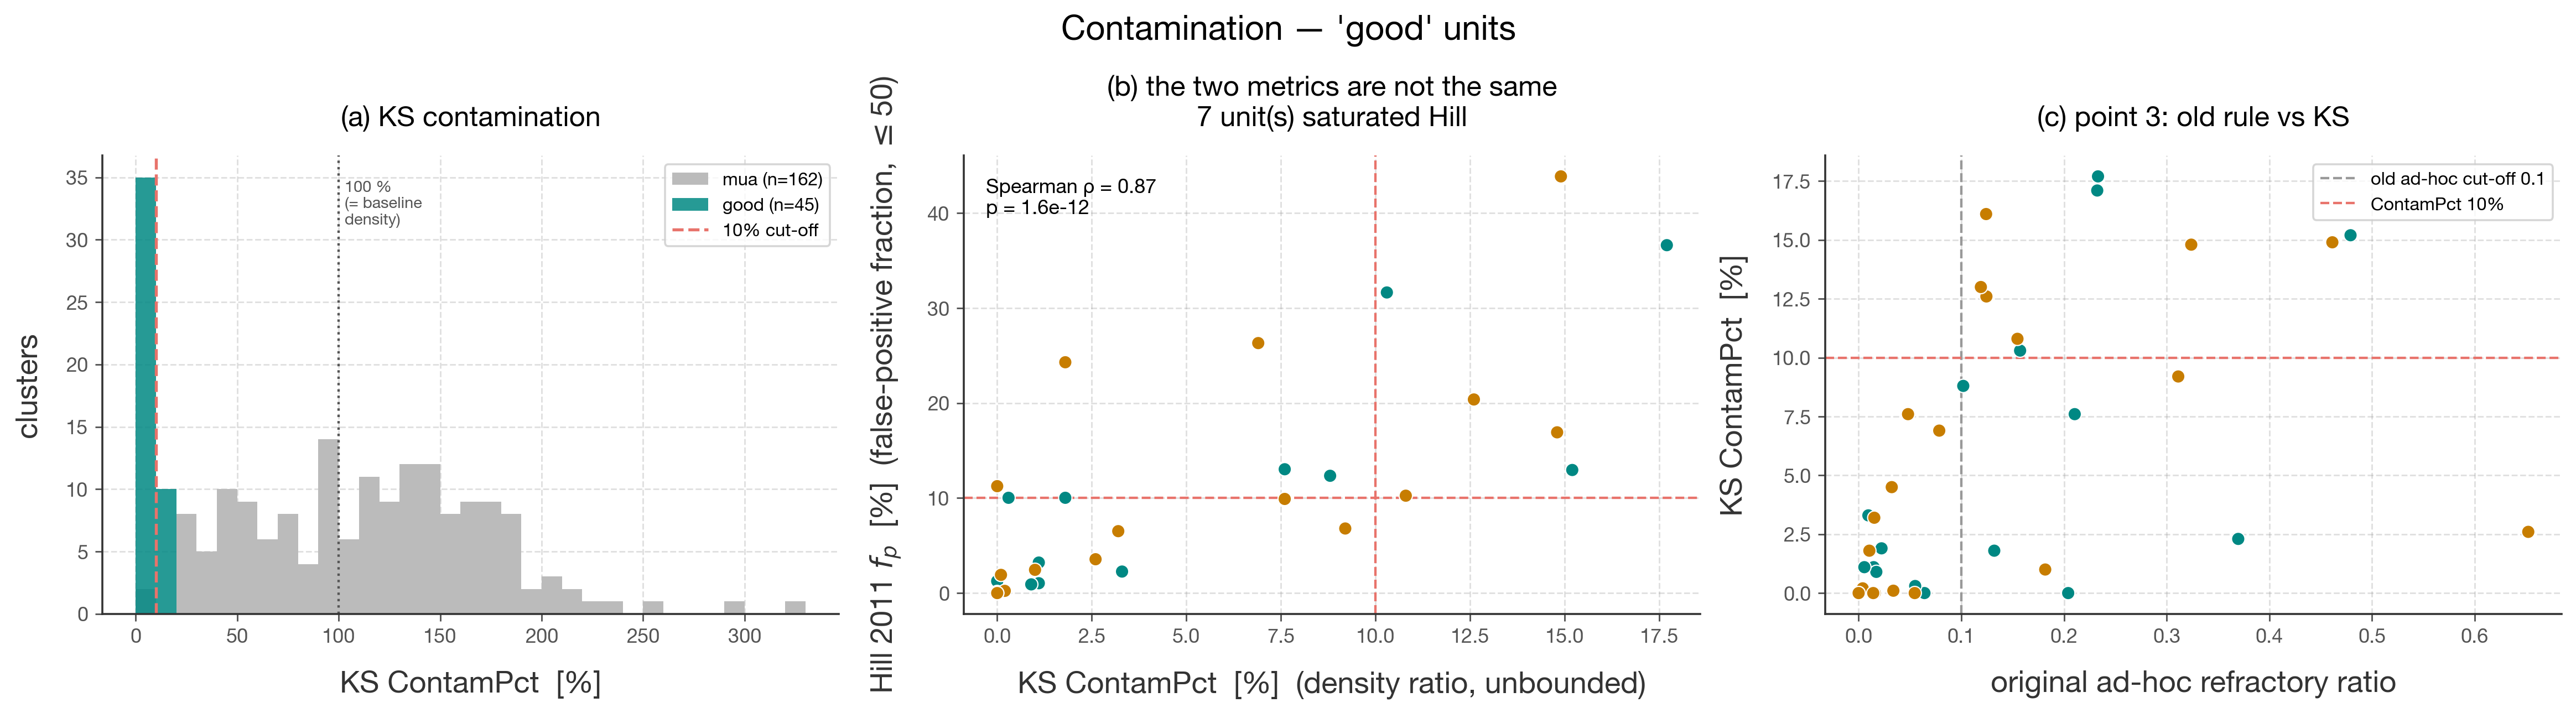

point 3 answer: old ad-hoc rule flagged 18/45 good units (40% — hence 'about half').
                KS ContamPct > 10% flags 10/45 (22%).
                median ContamPct: good 1.8%, mua 118.9%


In [ ]:
g = good_units
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# (a) ContamPct distribution, good vs mua
bins = np.arange(0, 340, 10)
ax[0].hist(mua_units.contam_pct, bins=bins, color="#BBBBBB", label=f"mua (n={len(mua_units)})")
ax[0].hist(g.contam_pct, bins=bins, color=CTX_COLOUR, alpha=0.85, label=f"good (n={len(g)})")
ax[0].axvline(CONTAM_CUTOFF, color=SOFT_RED, ls="--", lw=1.5, label=f"{CONTAM_CUTOFF:.0f}% cut-off")
ax[0].axvline(100, color="#555555", ls=":", lw=1.2)
ax[0].text(103, ax[0].get_ylim()[1] * 0.85, "100 %\n(= baseline\ndensity)", fontsize=8, color="#555555")
ax[0].set_xlabel("KS ContamPct  [%]"); ax[0].set_ylabel("clusters")
ax[0].set_title("(a) KS contamination", fontsize=14)
ax[0].legend(fontsize=9)

# (b) KS ContamPct vs Hill false-positive fraction
ok = g.hill_fp_pct.notna()
ax[1].scatter(g.loc[ok, "contam_pct"], g.loc[ok, "hill_fp_pct"], s=45,
              c=[CTX_COLOUR if x == "CTX" else HPC_COLOUR for x in g.loc[ok, "region"]],
              edgecolor="w", lw=0.6, zorder=3)
n_sat = int((~ok).sum())
ax[1].axvline(CONTAM_CUTOFF, color=SOFT_RED, ls="--", lw=1.2)
ax[1].axhline(CONTAM_CUTOFF, color=SOFT_RED, ls="--", lw=1.2)
ax[1].set_xlabel("KS ContamPct  [%]  (density ratio, unbounded)")
ax[1].set_ylabel(r"Hill 2011 $f_p$  [%]  (false-positive fraction, $\leq$50)")
ax[1].set_title(f"(b) the two metrics are not the same\n{n_sat} unit(s) saturated Hill",
                fontsize=14)
rho = sstats.spearmanr(g.loc[ok, "contam_pct"], g.loc[ok, "hill_fp_pct"])
ax[1].text(0.03, 0.95, f"Spearman ρ = {rho.statistic:.2f}\np = {rho.pvalue:.1e}",
           transform=ax[1].transAxes, va="top", fontsize=10)

# (c) KS ContamPct vs the original ad-hoc ratio
bins = np.arange(0, 340, 10)
ax[2].hist(mua_units.contam_pct, bins=bins, color="#BBBBBB", label=f"mua (n={len(mua_units)})")
ax[0].hist(g.contam_pct, bins=bins, color=CTX_COLOUR, alpha=0.85, label=f"good (n={len(g)})")
ax[0].axvline(CONTAM_CUTOFF, color=SOFT_RED, ls="--", lw=1.5, label=f"{CONTAM_CUTOFF:.0f}% cut-off")
ax[0].axvline(100, color="#555555", ls=":", lw=1.2)
ax[0].text(103, ax[0].get_ylim()[1] * 0.85, "100 %\n(= baseline\ndensity)", fontsize=8, color="#555555")
ax[0].set_xlabel("KS ContamPct  [%]"); ax[0].set_ylabel("clusters")
ax[0].set_title("(a) KS contamination", fontsize=14)
ax[0].legend(fontsize=9)
ax[2].scatter(g.ratio_original, g.contam_pct, s=45,
              c=[CTX_COLOUR if x == "CTX" else HPC_COLOUR for x in g.region],
              edgecolor="w", lw=0.6, zorder=3)
ax[2].axvline(0.1, color="#999999", ls="--", lw=1.2, label="old ad-hoc cut-off 0.1")
ax[2].axhline(CONTAM_CUTOFF, color=SOFT_RED, ls="--", lw=1.2, label=f"ContamPct {CONTAM_CUTOFF:.0f}%")
ax[2].set_xlabel("original ad-hoc refractory ratio")
ax[2].set_ylabel("KS ContamPct  [%]")
ax[2].set_title("(c) point 3: old rule vs KS", fontsize=14)
ax[2].legend(fontsize=9)

fig.suptitle("Contamination — 'good' units", fontsize=17, fontweight="bold")
fig.tight_layout()
show("contamination")

n_old = int((g.ratio_original > 0.1).sum())
n_new = int((g.contam_pct > CONTAM_CUTOFF).sum())
print(f"point 3 answer: old ad-hoc rule flagged {n_old}/{len(g)} good units "
      f"({100*n_old/len(g):.0f}% — hence 'about half').")
print(f"                KS ContamPct > {CONTAM_CUTOFF:.0f}% flags {n_new}/{len(g)} "
      f"({100*n_new/len(g):.0f}%).")
print(f"                median ContamPct: good {g.contam_pct.median():.1f}%, "
      f"mua {mua_units.contam_pct.median():.1f}%")

### Unit inclusion for everything below
`[CHANGED]` — the exclusion list is now KS `ContamPct` > 10 % rather than the ad-hoc ratio > 0.1,
plus a minimum spike count. The excluded units are listed so the choice is auditable.

In [168]:
clean = good_units[
    (good_units.contam_pct <= CONTAM_CUTOFF) & (good_units.n_spikes >= MIN_SPIKES_UNIT)
].copy().sort_values(["region", "depth_um"]).reset_index(drop=True)

excluded = good_units[~good_units.unit.isin(clean.unit)]
print(f"clean units: {len(clean)} of {len(good_units)} good "
      f"(CTX {int((clean.region=='CTX').sum())}, HPC {int((clean.region=='HPC').sum())})")
print("\nexcluded:")
print(excluded[["unit", "region", "depth_um", "fr_hz", "contam_pct", "n_spikes"]]
      .round(2).to_string(index=False))

clean units: 35 of 45 good (CTX 17, HPC 18)

excluded:
 unit region  depth_um  fr_hz  contam_pct  n_spikes
   30    CTX    555.85   6.07        10.3     15340
   50    CTX    766.49   8.66        17.7     21888
   49    CTX    790.23  12.93        15.2     32679
   57    CTX    799.14   3.42        17.1      8638
   89    HPC   1203.64  11.82        14.8     29880
  103    HPC   1363.61  15.61        10.8     39450
  109    HPC   1397.14   4.85        12.6     12263
  108    HPC   1402.91   0.50        13.0      1258
  138    HPC   1647.70   3.94        14.9      9960
  142    HPC   1676.19   2.61        16.1      6597


## Windowing Primitives

In [ ]:
def _gather(spikes, anchors, pre_samp, post_samp):
    """
    For every anchor, collect spike times relative to it within [-pre, +post].
    Fully vectorised. Returns (rel_samples, counts_per_anchor).
    """
    spk = np.sort(np.asarray(spikes))
    a   = np.asarray(anchors, dtype=np.int64)
    lo  = np.searchsorted(spk, a - pre_samp,  side="left")
    hi  = np.searchsorted(spk, a + post_samp, side="right")
    n   = hi - lo
    total = int(n.sum())
    if total == 0:
        return np.empty(0, dtype=np.int64), n
    starts = np.repeat(lo, n)
    offs   = np.arange(total) - np.repeat(np.cumsum(n) - n, n)
    rel    = spk[starts + offs] - np.repeat(a, n)
    return rel, n


def psth(spikes, onsets, pre_s, post_s, bin_s):
    """Firing rate [Hz] aligned to onsets. Returns (bin_centres_s, rate_hz)."""
    rel, _ = _gather(spikes, onsets, int(pre_s * FS), int(post_s * FS))
    edges  = np.arange(-pre_s, post_s + bin_s / 2, bin_s)
    counts, _ = np.histogram(rel / FS, bins=edges)
    centres = (edges[:-1] + edges[1:]) / 2
    return centres, counts / (bin_s * len(onsets))


def window_counts(spikes, anchors, lo_s, hi_s):
    """Spike count per anchor in [lo_s, hi_s) relative to the anchor."""
    spk = np.sort(np.asarray(spikes))
    a   = np.asarray(anchors, dtype=np.int64)
    return (np.searchsorted(spk, a + int(hi_s * FS), "left")
            - np.searchsorted(spk, a + int(lo_s * FS), "left"))


# Virtual "pooled" units (point 6) live here: negative id -> list of real cluster ids.
POOLED = {}

# One pass over the 3.75 M spikes to bucket them by cluster. Without this, every call below
# rescanned the full array; with 200+ clusters x 5 conditions x several analyses that dominated runtime.
_order       = np.argsort(spike_ids, kind="stable")
_uniq, _cnts = np.unique(spike_ids[_order], return_counts=True)
_edges       = np.r_[0, np.cumsum(_cnts)]

_SPIKES_BY_UNIT = {}
for _k, _u in enumerate(_uniq):
    _rows = _order[_edges[_k]:_edges[_k + 1]]
    _SPIKES_BY_UNIT[int(_u)] = np.sort(spike_times[_rows])


def spikes_of(unit_id):
    """
    Spike samples for a cluster id. Negative ids are virtual pooled units registered in POOLED,
    so every downstream routine can treat a pooled MUA train exactly like a single unit.
    """
    uid = int(unit_id)
    if uid >= 0:
        return _SPIKES_BY_UNIT.get(uid, np.empty(0, dtype=np.int64))
    if uid not in _SPIKES_BY_UNIT:
        _SPIKES_BY_UNIT[uid] = np.sort(np.concatenate(
            [_SPIKES_BY_UNIT[int(u)] for u in POOLED[uid]]))
    return _SPIKES_BY_UNIT[uid]

## 10. `[NEW #4]` Block PSTH — CTX above, HPC below, sorted by firing rate

Answering *"how are the units sorted?"*: in the old notebook they were not sorted at all — rows came
out in `cluster_id` order, which in Kilosort correlates with depth but is not depth and is not rate.
Now the row order is explicit and stated on the figure:

1. **block** — CTX (above `thetaCh`) on top, HPC below, separated by a black line
2. **within block** — descending mean firing rate

Each row is the unit's PSTH **z-scored against its own pre-stimulus baseline**
(mean and SD taken over the −2 → 0 s bins), so units with very different rates are comparable.

`[note]` 25 ms bins here. This panel answers *"does firing go up?"* and **cannot** show 40 Hz
following — one bin is exactly one 40 Hz cycle. That question is point 5.

In [ ]:
def block_psth_matrix(unit_table, condition, pre_s=PSTH_PRE_S, post_s=PSTH_POST_S, bin_s=PSTH_BIN_S):
    """
    Rows = units in `unit_table` order; values = z-score vs each unit's own pre-stimulus baseline.

    The baseline SD is **floored at the Poisson expectation** sqrt(mu / (bin * n_trials)).
    Without that floor a near-silent unit whose baseline bins happen to be almost identical gets a
    tiny empirical SD, and its z-scores saturate the colour scale purely from counting noise —
    which is what a raw z-scored PSTH heatmap of low-rate units always looks like.
    """
    onsets = TRIG[condition]["block_onsets"]
    rows, raw, kept = [], [], []
    for _, r in unit_table.iterrows():
        sp = spikes_of(r.unit)
        c, rate = psth(sp, onsets, pre_s, post_s, bin_s)
        base = c < 0
        mu, sd = rate[base].mean(), rate[base].std()
        sd_poisson = np.sqrt(max(mu, 1e-12) / (bin_s * len(onsets)))
        sd_eff = max(sd, sd_poisson)
        rows.append((rate - mu) / sd_eff if sd_eff > 0 else np.zeros_like(rate))
        raw.append(rate)
        kept.append(int(r.unit))
    return c, np.array(rows), np.array(raw), np.array(kept)


def order_ctx_hpc(unit_table):
    """Point 4's ordering: CTX block then HPC block, descending firing rate within each."""
    ctx = unit_table[unit_table.region == "CTX"].sort_values("fr_hz", ascending=False)
    hpc = unit_table[unit_table.region == "HPC"].sort_values("fr_hz", ascending=False)
    return pd.concat([ctx, hpc]).reset_index(drop=True), len(ctx)


ordered, n_ctx = order_ctx_hpc(clean)

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(4.1 * len(CONDITIONS), 9), sharey=True)
vmax = 6
for ax, cond in zip(axes, CONDITIONS):
    c, Z, _, kept = block_psth_matrix(ordered, cond)
    im = ax.imshow(Z, aspect="auto", cmap="RdBu_r",
                   norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax),
                   extent=[c[0], c[-1], len(kept) - 0.5, -0.5], interpolation="nearest")
    ax.axvline(0, color="k", lw=1.2)
    ax.axvline(4.0, color="k", lw=0.8, ls=":")
    ax.axhline(n_ctx - 0.5, color="k", lw=2.2)
    ax.set_title(cond, fontsize=13)
    ax.set_xlabel("time from block onset [s]")
    ax.grid(False)
axes[0].set_yticks(np.arange(len(ordered)))
axes[0].set_yticklabels([f"u{u} · {f:.1f} Hz" for u, f in zip(ordered.unit, ordered.fr_hz)],
                        fontsize=7)
axes[0].set_ylabel("unit", fontsize=13)
# colour the tick labels by region so the two blocks are readable without a legend
for lbl, reg in zip(axes[0].get_yticklabels(), ordered.region):
    lbl.set_color(CTX_COLOUR if reg == "CTX" else HPC_COLOUR)
    lbl.set_fontweight("bold")
cb = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
cb.set_label("z vs own pre-stimulus baseline", fontsize=11)
fig.suptitle(f"Block PSTH — {len(ordered)} clean units, {PSTH_BIN_S*1000:.0f} ms bins\n"
             f"rows: CTX above thetaCh ({THETA_DEPTH_UM:.0f} µm, n={n_ctx}, teal) then "
             f"HPC (n={len(ordered)-n_ctx}, orange); descending firing rate within each block",
             fontsize=16, fontweight="bold", y=0.97)
show("block_psth_clean")

### Responder metric

The professor's rule, implemented exactly as specified:

$$r_u = 100 \times \frac{\mathrm{FR}^{\text{stim}}_u - \mathrm{FR}^{\text{pre}}_u}{\mathrm{FR}^{\text{pre}}_u},
\qquad z_u = \frac{r_u - \overline{r}}{\mathrm{SD}(r)}, \qquad \text{responder} \iff |z_u| > 2$$

**Two problems with it, both real, both addressed by extra columns rather than by overruling him:**

1. **The z-score is relative to the population, not to noise.** If most units respond, the population SD
   is inflated by the very effect being detected and genuine responders fall below 2 SD. In V1 at 40 Hz
   that is the expected situation. It also guarantees ~2–5 % "responders" even from pure noise, because
   a z-score of a finite sample always has some tail.
2. **The ratio is unstable and skewed.** $\mathrm{FR}^{\text{pre}}$ appears in the denominator, and
   several clean units fire below 0.2 Hz — over a 2 s × 60-trial baseline that is a handful of spikes,
   so $r_u$ can be enormous or undefined. The distribution is bounded at $-100\%$ but unbounded above,
   which breaks the symmetry a z-score assumes.

So the table carries four columns:

| column | what it is |
|---|---|
| `z_pct` | **the professor's rule**, z of the raw % change — the headline |
| `z_log2` | z of $\log_2(\mathrm{FR}^{\text{stim}}/\mathrm{FR}^{\text{pre}})$ — same rule, symmetric scale |
| `mod_index` | $(S-P)/(S+P)$, bounded in $[-1, 1]$, well-behaved at low rates |
| `p_wilcoxon` | per-unit paired signed-rank on the 60 trial-wise counts, BH-FDR corrected — a *per-unit* null instead of a population one |

Agreement between the four is printed. Where they disagree, `p_wilcoxon` is the conservative reading.

In [ ]:
def responder_table(unit_table, condition, pre_s=PSTH_PRE_S, stim_s=4.0):
    onsets = TRIG[condition]["block_onsets"]
    rows = []
    for _, r in unit_table.iterrows():
        sp = spikes_of(r.unit)
        n_pre  = window_counts(sp, onsets, -pre_s, 0.0)
        n_stim = window_counts(sp, onsets, 0.0, stim_s)
        fr_pre, fr_stim = n_pre.sum() / (pre_s * len(onsets)), n_stim.sum() / (stim_s * len(onsets))

        # rate-matched per-trial counts for the paired test
        pre_rate, stim_rate = n_pre / pre_s, n_stim / stim_s
        if np.any(pre_rate != stim_rate):
            p = sstats.wilcoxon(stim_rate, pre_rate, zero_method="zsplit").pvalue
        else:
            p = 1.0

        rows.append({
            "unit": int(r.unit), "region": r.region, "depth_um": r.depth_um,
            "fr_pre": fr_pre, "fr_stim": fr_stim,
            "pct_change": 100 * (fr_stim - fr_pre) / fr_pre if fr_pre > 0 else np.nan,
            "log2_ratio": np.log2(fr_stim / fr_pre) if (fr_pre > 0 and fr_stim > 0) else np.nan,
            "mod_index": (fr_stim - fr_pre) / (fr_stim + fr_pre) if (fr_stim + fr_pre) > 0 else np.nan,
            "p_raw": p,
        })
    df = pd.DataFrame(rows)
    df["z_pct"]  = (df["pct_change"] - df["pct_change"].mean()) / df["pct_change"].std()
    df["z_log2"] = (df.log2_ratio - df.log2_ratio.mean()) / df.log2_ratio.std()
    df["p_fdr"]  = benjamini_hochberg(df.p_raw.values)
    df["responder_z2sd"] = df.z_pct.abs() > RESPONDER_Z
    df["responder_wilcoxon"] = df.p_fdr < 0.05
    df["condition"] = condition
    return df


def benjamini_hochberg(p):
    p = np.asarray(p, dtype=float)
    n = p.size
    order = np.argsort(p)
    q = np.empty(n)
    q[order] = np.minimum.accumulate((p[order] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.minimum(q, 1.0)


resp = pd.concat([responder_table(clean, c) for c in CONDITIONS], ignore_index=True)

print("responders per condition (of %d clean units)\n" % len(clean))
tab = (resp.groupby(["condition", "region"])
           .agg(n=("unit", "size"),
                z2sd=("responder_z2sd", "sum"),
                wilcoxon_FDR=("responder_wilcoxon", "sum"),
                median_pct=("pct_change", "median"))
           .round(1))
print(tab.to_string())
agree = (resp.responder_z2sd == resp.responder_wilcoxon).mean()
print(f"\nthe two definitions agree on {100*agree:.0f}% of unit×condition cells")

In [ ]:
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(3.6 * len(CONDITIONS), 6), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    d = resp[resp.condition == cond]
    for reg, col in (("CTX", CTX_COLOUR), ("HPC", HPC_COLOUR)):
        dd = d[d.region == reg]
        ax.scatter(dd.z_pct, dd.depth_um, s=55, color=col, edgecolor="w", lw=0.6,
                   label=reg, zorder=3)
    sig = d[d.responder_wilcoxon]
    ax.scatter(sig.z_pct, sig.depth_um, s=150, facecolor="none", edgecolor="k", lw=1.0,
               zorder=2, label="Wilcoxon FDR<0.05")
    for x in (-RESPONDER_Z, RESPONDER_Z):
        ax.axvline(x, color=SOFT_RED, ls="--", lw=1.2)
    ax.axhline(THETA_DEPTH_UM, color="k", lw=1.5)
    ax.set_title(cond, fontsize=12)
    ax.set_xlabel("z of % change  (the professor's rule)")
axes[0].invert_yaxis()
axes[0].set_ylabel("depth [µm]   —   line = thetaCh")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Responders by depth — soft red = ±2 SD cut-off", fontsize=16, fontweight="bold")
fig.tight_layout()
show("responders_by_depth")

## 11. `[NEW #5]` Transition-triggered PSTH and modulation depth

This asks the different question the professor describes: not *"does the block drive the unit?"* but
*"does the unit follow each individual screen transition?"*

For each condition every transition is a trigger — 60 blocks × 160 = **9600 triggers at 40 Hz**,
60 × 80 = **4800 at 20 Hz** — and the histogram spans **3.5 cycles** at **1 ms** bins (25 bins/cycle
at 40 Hz). A rhythmically following unit produces the sine-like counts he describes.

**Two things to keep in mind when reading these panels** `[established]`:

* The windows **overlap**: a ±1.75-cycle window around triggers spaced 1 cycle apart means each spike
  is counted in ~3.5 windows. The rate axis is still correct (divided by trigger count), but adjacent
  cycles in the plot are *not independent* — the histogram is periodic **by construction**. The
  informative object is a single cycle; the 3.5 cycles are for legibility, exactly as he asked.
* A flat histogram is the null. It does **not** mean the unit is silent — it means unmodulated.

### Modulation depth

His definition, $\mathrm{MD} = \mathrm{FR}_{\text{peak}} / \mathrm{FR}_{\text{trough}}$, is computed.
Two caveats, so two extra columns:

* MD **diverges** as the trough approaches zero, and is **biased upward at low spike counts** because
  peak and trough are order statistics — sampling noise alone pushes them apart. Units here differ in
  rate by 400×, so raw MD is not comparable across units.
* `mod_depth_norm` $= (P - T)/(P + T) \in [0, 1]$ is bounded and far more stable.
* `vs` (vector strength) and `ppc` quantify the same thing without a peak-picking step.
  $\mathrm{VS} = \frac{1}{N}\left|\sum_k e^{i\theta_k}\right|$ is itself **biased upward at low N**, so
  `ppc` — the bias-free pairwise phase consistency, $\mathrm{PPC} = \frac{|\sum e^{i\theta}|^2 - N}{N(N-1)}$
  (Vinck et al. 2010, *NeuroImage* 51:112) — is the column to use for any CTX-vs-HPC comparison, because
  the two regions have systematically different firing rates and VS would confound rate with locking.

Peak and trough are read off a 3-bin boxcar-smoothed cycle histogram, otherwise a single noisy bin sets
the value.

In [ ]:
def cycle_phases(spikes, transitions, period_s):
    """
    Phase of each spike within the stimulus cycle, in radians.
    A spike is included only if it falls in [transition, transition + period) for some transition,
    which automatically restricts the analysis to in-block spikes.
    """
    spk = np.sort(np.asarray(spikes))
    tr  = np.asarray(transitions, dtype=np.int64)
    idx = np.searchsorted(tr, spk, side="right") - 1
    ok  = idx >= 0
    dt  = np.full(spk.shape, np.inf)
    dt[ok] = (spk[ok] - tr[idx[ok]]) / FS
    ok &= (dt >= 0) & (dt < period_s)
    return 2 * np.pi * dt[ok] / period_s


def transition_response(spikes, condition, cycles=TT_CYCLES, bin_ms=TT_BIN_MS):
    """Transition-triggered rate over `cycles` cycles + modulation/locking metrics."""
    tr, period = TRIG[condition]["transitions"], TRIG[condition]["period_s"]
    half_s = cycles / 2 * period
    bin_s  = bin_ms / 1000.0

    rel, _ = _gather(spikes, tr, int(half_s * FS), int(half_s * FS))
    edges  = np.arange(-half_s, half_s + bin_s / 2, bin_s)
    counts, _ = np.histogram(rel / FS, bins=edges)
    centres = (edges[:-1] + edges[1:]) / 2
    rate = counts / (bin_s * tr.size)

    # ---- one-cycle histogram for the metrics -------------------------------------
    # IMPORTANT: this is built from `cycle_phases`, which assigns each spike to the ONE
    # transition that precedes it, so every spike is counted exactly once.
    #
    # The obvious alternative -- folding the plotted window with `(rel / FS) % period` --
    # is WRONG whenever the window is not a whole number of cycles. With TT_CYCLES = 3.5 the
    # interval [-1.75P, +1.75P] covers phases below 0.75P four times and phases above it three
    # times, so a perfectly FLAT spike train folds to a 4:3 step and reads peak/trough = 1.33.
    # That is a pure geometry artifact with no neural content, and it is close to the real
    # modulation depths here, so it would have been easy to believe. Verified by folding
    # uniform random numbers: 3.5 cycles -> 1.34, whole numbers of cycles -> 1.01.
    theta = cycle_phases(spikes, tr, period)
    n = theta.size

    nb_cycle = int(round(period / bin_s))
    ce = np.arange(nb_cycle + 1) * bin_s
    cyc_counts, _ = np.histogram(theta / (2 * np.pi) * period, bins=ce)
    cyc_rate = cyc_counts / (bin_s * tr.size)          # each trigger contributes one cycle
    k = np.ones(3) / 3.0
    sm = np.convolve(np.r_[cyc_rate[-1], cyc_rate, cyc_rate[0]], k, mode="same")[1:-1]
    peak, trough = sm.max(), sm.min()
    if n > 1:
        R = np.abs(np.sum(np.exp(1j * theta)))
        vs  = R / n
        ppc = (R ** 2 - n) / (n * (n - 1))
        rayleigh_p = np.exp(np.sqrt(1 + 4 * n + 4 * (n ** 2 - R ** 2)) - (1 + 2 * n))
        pref_phase = float(np.angle(np.sum(np.exp(1j * theta))) % (2 * np.pi))
    else:
        vs = ppc = np.nan; rayleigh_p = 1.0; pref_phase = np.nan

    return dict(centres=centres, rate=rate, cycle_rate=cyc_rate, cycle_edges=ce,
                n_triggers=tr.size, n_cycle_spikes=n,
                mod_depth=peak / trough if trough > 0 else np.inf,
                mod_depth_norm=(peak - trough) / (peak + trough) if (peak + trough) > 0 else np.nan,
                fr_peak=peak, fr_trough=trough,
                vs=vs, ppc=ppc, rayleigh_p=rayleigh_p, pref_phase=pref_phase)


def transition_table(unit_table, conditions=FLICKER_CONDITIONS):
    rows = []
    for cond in conditions:
        for _, r in unit_table.iterrows():
            sp = spikes_of(r.unit)
            m = transition_response(sp, cond)
            rows.append({
                "unit": int(r.unit), "region": r.region, "depth_um": r.depth_um,
                "fr_hz": r.fr_hz, "condition": cond,
                "n_cycle_spikes": m["n_cycle_spikes"],
                "mod_depth": m["mod_depth"], "mod_depth_norm": m["mod_depth_norm"],
                "fr_peak": m["fr_peak"], "fr_trough": m["fr_trough"],
                "vs": m["vs"], "ppc": m["ppc"], "rayleigh_p": m["rayleigh_p"],
                "pref_phase_deg": np.degrees(m["pref_phase"]),
            })
    df = pd.DataFrame(rows)
    df["reliable"] = df.n_cycle_spikes >= TT_MIN_SPIKES
    for cond in conditions:
        m = df.condition == cond
        df.loc[m, "rayleigh_p_fdr"] = benjamini_hochberg(df.loc[m, "rayleigh_p"].values)
    return df

### `[NEW — verification]` The locking metrics, checked against synthetic ground truth

None of the numbers above are trustworthy until the estimator is shown to return the right answer on
data whose answer is known. Three synthetic trains, each fed through the identical `transition_response`
used for the real units:

| train | truth | expected |
|---|---|---|
| Poisson, no stimulus relation | unmodulated | VS ≈ 0, PPC ≈ 0, Rayleigh n.s., MD ≈ 1 |
| von Mises concentrated at one phase | strongly locked | VS high, PPC high, Rayleigh p ≈ 0 |
| two peaks half a cycle apart | locked at $2f_0$, not $f_0$ | VS ≈ 0 despite obvious structure |

The third row is the n:1 blind spot of vector strength, and is why the harmonic control below exists.
The first row also pins the **noise floor of peak/trough**: MD is a ratio of order statistics, so it
sits above 1 even for a perfectly flat train, and that floor rises as spike count falls.

In [ ]:
def _synthetic(kind, n_spikes, condition="flicker_40Hz", seed=0):
    """Place n_spikes at controlled phases relative to the real trigger train."""
    rng = np.random.default_rng(seed)
    tr, P = TRIG[condition]["transitions"], TRIG[condition]["period_s"]
    base = rng.choice(tr, size=n_spikes, replace=True)
    if kind == "flat":
        ph = rng.uniform(0, P, n_spikes)
    elif kind == "locked":
        ph = (rng.vonmises(0.0, 4.0, n_spikes) / (2 * np.pi) + 0.5) * P
    elif kind == "two_peak":
        ph = ((rng.vonmises(0.0, 20.0, n_spikes) / (2 * np.pi) + 0.5) * P / 2
              + rng.integers(0, 2, n_spikes) * P / 2)
    return np.sort(base + (ph * FS).astype(np.int64))


print(f"{'train':>10} {'N':>8} {'VS':>8} {'PPC':>9} {'Rayleigh p':>12} {'MD':>7} {'MDnorm':>8}")
for kind in ("flat", "locked", "two_peak"):
    for n_sp in (50_000, 2_000):
        m = transition_response(_synthetic(kind, n_sp), "flicker_40Hz")
        print(f"{kind:>10} {n_sp:8d} {m['vs']:8.4f} {m['ppc']:9.5f} "
              f"{m['rayleigh_p']:12.2e} {m['mod_depth']:7.3f} {m['mod_depth_norm']:8.3f}")

m_flat = transition_response(_synthetic("flat", 50_000), "flicker_40Hz")
assert m_flat["mod_depth"] < 1.25, (
    "flat train should give peak/trough near 1 — if it does not, the cycle histogram is "
    "double-counting spikes (see the folding note above)")
print("\n[check passed] a flat train folds to peak/trough "
      f"{m_flat['mod_depth']:.3f}, i.e. no geometry artifact.")

In [ ]:
tt = transition_table(ordered)
print(tt.groupby(["condition", "region"])
        .agg(n=("unit", "size"),
             median_MD=("mod_depth", "median"),
             median_MDnorm=("mod_depth_norm", "median"),
             median_PPC=("ppc", "median"),
             locked_FDR05=("rayleigh_p_fdr", lambda x: int((x < 0.05).sum())))
        .round(3).to_string())

In [ ]:
# --- transition-triggered PSTH grid, one figure per condition -------------------
for cond in FLICKER_CONDITIONS:
    period_ms = TRIG[cond]["period_s"] * 1000
    ncol = 6
    nrow = int(np.ceil(len(ordered) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.9 * ncol, 2.0 * nrow))
    for ax, (_, r) in zip(axes.ravel(), ordered.iterrows()):
        m = transition_response(spikes_of(int(r.unit)), cond)
        reliable = m["n_cycle_spikes"] >= TT_MIN_SPIKES
        col = (CTX_COLOUR if r.region == "CTX" else HPC_COLOUR) if reliable else "#BBBBBB"
        ax.step(m["centres"] * 1000, m["rate"], where="mid", color=col, lw=1.0)
        ax.fill_between(m["centres"] * 1000, m["rate"], step="mid", color=col, alpha=0.2, lw=0)
        for k in np.arange(-2, 3) * period_ms:
            ax.axvline(k, color=SOFT_RED, ls="--", lw=0.8, alpha=0.8)
        ax.set_title(f"u{int(r.unit)} · {r.region}", fontsize=9, fontweight="bold", pad=3,
                     color="#333333" if reliable else "#999999")
        star = "*" if m["rayleigh_p"] < 0.05 else ""
        label = (f"MD {m['mod_depth']:.2f}{star}\nnorm {m['mod_depth_norm']:.2f}\n"
                 f"PPC {m['ppc']:.4f}") if reliable else \
                f"only {m['n_cycle_spikes']} spikes\nmetrics not shown"
        ax.text(0.02, 0.95, label, transform=ax.transAxes, va="top", fontsize=7,
                color="#333333" if reliable else "#999999",
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5), zorder=5)
        ax.set_xlim(m["centres"][0] * 1000, m["centres"][-1] * 1000)
        ax.tick_params(labelsize=6); ax.grid(alpha=0.15)
    for ax in axes.ravel()[len(ordered):]:
        ax.axis("off")
    fig.suptitle(f"Transition-triggered PSTH — {cond} "
                 f"({TRIG[cond]['transitions'].size:,} triggers, {TT_BIN_MS:.0f} ms bins, "
                 f"{TT_CYCLES} cycles)\nsoft red = transition times · "
                 f"MD = peak/trough (* Rayleigh p<0.05)",
                 fontsize=15, fontweight="bold", y=1.0)
    fig.tight_layout()
    show(f"transition_grid_{cond}")

In [ ]:
# --- modulation depth and PPC vs depth ------------------------------------------
fig, axes = plt.subplots(2, len(FLICKER_CONDITIONS),
                         figsize=(3.6 * len(FLICKER_CONDITIONS), 10), sharey=True)
for j, cond in enumerate(FLICKER_CONDITIONS):
    d = tt[(tt.condition == cond) & tt.reliable]
    for i, (col, lab, logx) in enumerate([("mod_depth_norm", "(peak−trough)/(peak+trough)", False),
                                          ("ppc", "PPC (bias-free)", False)]):
        ax = axes[i, j]
        for reg, c in (("CTX", CTX_COLOUR), ("HPC", HPC_COLOUR)):
            dd = d[d.region == reg]
            ax.scatter(dd[col], dd.depth_um, s=55, color=c, edgecolor="w", lw=0.6, zorder=3, label=reg)
        sig = d[d.rayleigh_p_fdr < 0.05]
        ax.scatter(sig[col], sig.depth_um, s=150, facecolor="none", edgecolor="k", lw=1.0, zorder=2)
        ax.axhline(THETA_DEPTH_UM, color="k", lw=1.5)
        ax.set_xlabel(lab, fontsize=11)
        if i == 0:
            ax.set_title(cond, fontsize=12)
axes[0, 0].invert_yaxis()
for i in range(2):
    axes[i, 0].set_ylabel("depth [µm]")
axes[0, 0].legend(fontsize=9)
fig.suptitle("Cycle-by-cycle locking vs depth  (black ring = Rayleigh FDR<0.05)",
             fontsize=16, fontweight="bold")
fig.tight_layout()
show("locking_vs_depth")

### Harmonic control — is the weak 40 Hz locking real?

The result that comes out of the cells above is that **cortical units lock far more strongly to 20 Hz
than to 40 Hz** (median CTX PPC ≈ 0.028 at 20 Hz vs ≈ 0.000 at 40 Hz; 14/17 vs 5/17 significant by
Rayleigh at FDR < 0.05). Given that 20 Hz is meant to be the negative-control frequency, that needs a
defence before it goes anywhere near the report.

The obvious artifactual explanation is the **n:1 locking blind spot of vector strength** `[established]`:
if a unit fires twice per stimulus cycle at opposite phases — e.g. once to the light going on and once
to it going off — the two phase vectors cancel and VS reads ≈ 0 despite perfect entrainment.
The analog channel logs only **one edge per cycle** (9600 events / 60 blocks / 4 s = 40 Hz for a 40 Hz
flicker that physically has 80 transitions per second), so this is a live possibility, not a hypothetical.

The test: recompute VS, PPC **and the Rayleigh test** at the **second harmonic** (period halved).
The diagnostic is not "which harmonic is larger on average" — for an unmodulated unit that is a coin
flip carrying no information. It is whether **any unit is significantly locked at $2f_0$ while not
locked at $f_0$**, which is the only signature of a cancelled two-peak response.

In [ ]:
def vs_ppc_at_harmonic(spikes, condition, harmonic=1):
    """VS and PPC computed against period/harmonic, restricted to in-block spikes as before."""
    tr, period = TRIG[condition]["transitions"], TRIG[condition]["period_s"]
    spk = np.sort(np.asarray(spikes))
    idx = np.searchsorted(tr, spk, "right") - 1
    ok  = idx >= 0
    dt  = np.full(spk.shape, np.inf)
    dt[ok] = (spk[ok] - tr[idx[ok]]) / FS
    ok &= (dt >= 0) & (dt < period)
    p_h = period / harmonic
    theta = 2 * np.pi * (dt[ok] % p_h) / p_h
    n = theta.size
    R = np.abs(np.sum(np.exp(1j * theta)))
    return R / n, (R ** 2 - n) / (n * (n - 1)), n


harm = []
for cond in ["flicker_40Hz", "flicker_20Hz"]:
    for _, r in ordered.iterrows():
        sp = spikes_of(r.unit)
        row = {"unit": int(r.unit), "region": r.region, "condition": cond}
        for h, tag in [(1, "f0"), (2, "2f0")]:
            v, pp, n = vs_ppc_at_harmonic(sp, cond, h)
            R = v * n
            row[f"vs_{tag}"], row[f"ppc_{tag}"] = v, pp
            # Rayleigh, same closed form used in transition_response
            row[f"p_{tag}"] = np.exp(np.sqrt(1 + 4 * n + 4 * (n ** 2 - R ** 2)) - (1 + 2 * n))
        row["n"] = n
        harm.append(row)
harm = pd.DataFrame(harm)
for cond in harm.condition.unique():
    m = harm.condition == cond
    for tag in ("f0", "2f0"):
        harm.loc[m, f"q_{tag}"] = benjamini_hochberg(harm.loc[m, f"p_{tag}"].values)
harm["reliable"] = harm.n >= TT_MIN_SPIKES

# The diagnostic pattern is NOT "which harmonic is bigger on average" -- for an unmodulated unit
# that is a coin flip and tells you nothing. It is whether any unit locks at 2f0 WITHOUT locking
# at f0, which is the only signature of the cancellation blind spot.
print("locked at f0 / locked at 2f0  (Rayleigh, BH-FDR < 0.05; reliable units only)\n")
for cond in ["flicker_40Hz", "flicker_20Hz"]:
    x = harm[(harm.condition == cond) & harm.reliable]
    ct = pd.crosstab([x.region], [x.q_f0 < 0.05, x.q_2f0 < 0.05],
                     rownames=["region"], colnames=["f0", "2f0"])
    only2 = int(((x.q_2f0 < 0.05) & (x.q_f0 >= 0.05)).sum())
    lk = x[(x.q_f0 < 0.05) | (x.q_2f0 < 0.05)]
    print(f"--- {cond}")
    print(ct.to_string())
    print(f"    locked at 2f0 but NOT f0: {only2}")
    print(f"    of the {len(lk)} locked units, VS_f0 > VS_2f0 in "
          f"{int((lk.vs_f0 > lk.vs_2f0).sum())}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, cond in zip(axes, ["flicker_40Hz", "flicker_20Hz"]):
    d = harm[(harm.condition == cond) & harm.reliable]
    for reg, c in (("CTX", CTX_COLOUR), ("HPC", HPC_COLOUR)):
        dd = d[d.region == reg]
        ax.scatter(dd.vs_f0, dd.vs_2f0, s=60, color=c, edgecolor="w", lw=0.6, label=reg, zorder=3)
    sig = d[d.q_f0 < 0.05]
    ax.scatter(sig.vs_f0, sig.vs_2f0, s=155, facecolor="none", edgecolor="k", lw=1.0,
               zorder=2, label="locked at $f_0$ (FDR<0.05)")
    lim = [0, max(0.05, d[["vs_f0", "vs_2f0"]].to_numpy().max() * 1.15)]
    ax.plot(lim, lim, color="#999999", ls="--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("VS at fundamental $f_0$"); ax.set_ylabel("VS at 2nd harmonic $2f_0$")
    ax.set_title(cond, fontsize=13)
    ax.legend(fontsize=9)
fig.suptitle("Harmonic control — every locked unit sits BELOW the diagonal, and none locks at\n"
             "$2f_0$ alone, so no response is being cancelled by the vector-strength blind spot",
             fontsize=15, fontweight="bold")
fig.tight_layout()
show("harmonic_control")

print("[conclusion] No unit, at either frequency, locks at 2f0 without also locking at f0 -- so no\n"
      "genuine two-peaks-per-cycle response is being hidden by vector-strength cancellation. The weak\n"
      "40 Hz locking is a real failure to follow the flicker cycle by cycle. At 20 Hz several units are\n"
      "significant at BOTH harmonics, which is simply the harmonic content of a sharp, non-sinusoidal\n"
      "peak -- VS_f0 exceeds VS_2f0 in every locked unit. This is consistent with the temporal low-pass\n"
      "behaviour of the early visual system and does NOT contradict the 40 Hz amyloid literature, which\n"
      "rests on LFP power, not on spike phase-locking. Worth raising with the professor explicitly, since\n"
      "20 Hz is nominally the control frequency.")

## 12. `[NEW #6]` The same two analyses on MUA

Done in the two stages you asked for:

* **12a — each `mua` cluster separately** (162 clusters, 57 CTX / 105 HPC). Same block PSTH, same
  responder rule, same transition-triggered modulation.
* **12b — pooled per region.** All CTX `mua` spikes merged into one train, all HPC `mua` spikes into
  another. These are registered as virtual units `-1` (CTX) and `-2` (HPC) so every routine above works
  on them unchanged.

**No contamination filter is applied to MUA** — that is the point of the label. Their median
`ContamPct` is ~119 %, i.e. refractory windows *fuller* than baseline, exactly what a merge of several
neurons looks like. Consequences that must be stated when this is reported `[established]`:

* **Pooled MUA has no refractory period**, so the ACG/contamination diagnostics above are meaningless
  for it and are not computed.
* MUA *rate* changes are interpretable; MUA *waveform-level* claims are not.
* Pooled MUA is dominated by its highest-rate members, so it is closer to "population rate near these
  contacts" than to "the average neuron". A large pooled modulation is consistent with a few strongly
  driven units rather than broad engagement — worth saying explicitly in the report.

In [ ]:
# ---- 12a: each mua cluster separately -----------------------------------------
mua_ordered, mua_n_ctx = order_ctx_hpc(mua_units[mua_units.n_spikes >= MIN_SPIKES_UNIT])
print(f"12a — {len(mua_ordered)} mua clusters "
      f"(CTX {mua_n_ctx}, HPC {len(mua_ordered)-mua_n_ctx})")

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(4.1 * len(CONDITIONS), 11), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    c, Z, _, kept = block_psth_matrix(mua_ordered, cond)
    im = ax.imshow(Z, aspect="auto", cmap="RdBu_r",
                   norm=TwoSlopeNorm(vcenter=0, vmin=-6, vmax=6),
                   extent=[c[0], c[-1], len(kept) - 0.5, -0.5], interpolation="nearest")
    ax.axvline(0, color="k", lw=1.2)
    ax.axhline(mua_n_ctx - 0.5, color="k", lw=2.2)
    ax.set_title(cond, fontsize=13)
    ax.set_xlabel("time from block onset [s]")
    ax.grid(False)
axes[0].set_ylabel("MUA cluster", fontsize=13)
axes[0].set_yticks([0, mua_n_ctx - 1, mua_n_ctx, len(mua_ordered) - 1])
axes[0].set_yticklabels([f"CTX 1", f"CTX {mua_n_ctx}",
                         "HPC 1", f"HPC {len(mua_ordered)-mua_n_ctx}"], fontsize=9)
for lbl, col in zip(axes[0].get_yticklabels(),
                    [CTX_COLOUR, CTX_COLOUR, HPC_COLOUR, HPC_COLOUR]):
    lbl.set_color(col); lbl.set_fontweight("bold")
cb = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
cb.set_label("z vs own pre-stimulus baseline", fontsize=11)
fig.suptitle(f"Point 6 — block PSTH, {len(mua_ordered)} individual MUA clusters "
             f"(CTX n={mua_n_ctx} top / HPC n={len(mua_ordered)-mua_n_ctx} bottom, "
             f"descending rate)", fontsize=16, fontweight="bold", y=0.96)
show("mua_block_psth_individual")

mua_resp = pd.concat([responder_table(mua_ordered, c) for c in CONDITIONS], ignore_index=True)
mua_tt   = transition_table(mua_ordered)
print(mua_resp.groupby(["condition", "region"])
              .agg(n=("unit", "size"),
                   z2sd=("responder_z2sd", "sum"),
                   wilcoxon_FDR=("responder_wilcoxon", "sum"),
                   median_pct=("pct_change", "median")).round(1).to_string())

In [ ]:
# ---- 12b: pooled per region ----------------------------------------------------
POOLED[-1] = mua_units.loc[mua_units.region == "CTX", "unit"].astype(int).tolist()
POOLED[-2] = mua_units.loc[mua_units.region == "HPC", "unit"].astype(int).tolist()

pooled = pd.DataFrame([
    {"unit": -1, "label": "mua_pooled", "region": "CTX",
     "depth_um": float(mua_units.loc[mua_units.region == "CTX", "depth_um"].median()),
     "n_spikes": int(mua_units.loc[mua_units.region == "CTX", "n_spikes"].sum()),
     "contam_pct": np.nan},
    {"unit": -2, "label": "mua_pooled", "region": "HPC",
     "depth_um": float(mua_units.loc[mua_units.region == "HPC", "depth_um"].median()),
     "n_spikes": int(mua_units.loc[mua_units.region == "HPC", "n_spikes"].sum()),
     "contam_pct": np.nan},
])
pooled["fr_hz"] = pooled.n_spikes / REC_DUR_S
print(pooled.round(2).to_string(index=False))

pooled_resp = pd.concat([responder_table(pooled, c) for c in CONDITIONS], ignore_index=True)
pooled_tt   = transition_table(pooled)

fig, axes = plt.subplots(2, len(CONDITIONS), figsize=(3.6 * len(CONDITIONS), 8), sharex="col")
for j, cond in enumerate(CONDITIONS):
    for i, (uid, reg, col) in enumerate([(-1, "CTX", CTX_COLOUR), (-2, "HPC", HPC_COLOUR)]):
        ax = axes[i, j]
        c, rate = psth(spikes_of(uid), TRIG[cond]["block_onsets"],
                       PSTH_PRE_S, PSTH_POST_S, PSTH_BIN_S)
        base = rate[c < 0].mean()
        ax.fill_between(c, rate, step="mid", color=col, alpha=0.25, lw=0)
        ax.step(c, rate, where="mid", color=col, lw=1.2)
        ax.axhline(base, color="#555555", ls="--", lw=1.0)
        ax.axvspan(-PSTH_PRE_S, 0, color="#BBBBBB", alpha=0.18, lw=0)
        ax.axvline(0, color="k", lw=1.0)
        d = pooled_resp[(pooled_resp.condition == cond) & (pooled_resp.unit == uid)].iloc[0]
        ax.text(0.02, 0.95, f"{d['pct_change']:+.1f}%\nMI {d.mod_index:+.3f}\np {d.p_raw:.1e}",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5), zorder=5)
        if i == 0:
            ax.set_title(cond, fontsize=12)
        if j == 0:
            ax.set_ylabel(f"pooled {reg} MUA\nrate [Hz]", fontsize=11)
        if i == 1:
            ax.set_xlabel("time from onset [s]")
fig.suptitle("Point 6 — pooled MUA block PSTH (grey band = baseline window)",
             fontsize=16, fontweight="bold")
fig.tight_layout()
show("mua_pooled_block_psth")

In [ ]:
# ---- 12b: pooled MUA, transition-triggered -------------------------------------
fig, axes = plt.subplots(2, len(FLICKER_CONDITIONS),
                         figsize=(3.6 * len(FLICKER_CONDITIONS), 8))
for j, cond in enumerate(FLICKER_CONDITIONS):
    period_ms = TRIG[cond]["period_s"] * 1000
    for i, (uid, reg, col) in enumerate([(-1, "CTX", CTX_COLOUR), (-2, "HPC", HPC_COLOUR)]):
        ax = axes[i, j]
        m = transition_response(spikes_of(uid), cond)
        ax.fill_between(m["centres"] * 1000, m["rate"], step="mid", color=col, alpha=0.25, lw=0)
        ax.step(m["centres"] * 1000, m["rate"], where="mid", color=col, lw=1.3)
        for k in np.arange(-2, 3) * period_ms:
            ax.axvline(k, color=SOFT_RED, ls="--", lw=0.9, alpha=0.8)
        ax.text(0.02, 0.95,
                f"MD {m['mod_depth']:.3f}\nnorm {m['mod_depth_norm']:.3f}\n"
                f"PPC {m['ppc']:.5f}\nRayleigh p {m['rayleigh_p']:.1e}",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5), zorder=5)
        ax.set_xlim(m["centres"][0] * 1000, m["centres"][-1] * 1000)
        if i == 0:
            ax.set_title(cond, fontsize=12)
        if j == 0:
            ax.set_ylabel(f"pooled {reg} MUA\nrate [Hz]", fontsize=11)
        if i == 1:
            ax.set_xlabel("time from transition [ms]")
fig.suptitle("Point 6 — pooled MUA, transition-triggered (soft red = transitions)",
             fontsize=16, fontweight="bold")
fig.tight_layout()
show("mua_pooled_transition")

print(pooled_tt[["unit", "region", "condition", "n_cycle_spikes", "mod_depth",
                 "mod_depth_norm", "vs", "ppc", "rayleigh_p"]].round(5).to_string(index=False))

## 13. `[NEW #7]` Static — spike counts before vs during

*"for the static stimulus, we can only compare spike counts before vs during for each cluster.
e.g. 2 s right before vs 2 s right after the start."* Implemented exactly that: per cluster, per trial,
count spikes in **[−2, 0) s** and **[0, +2) s** around each of the 60 static onsets.

Because the two windows are the same length the counts are directly comparable with no rate correction.
The test is a **paired Wilcoxon signed-rank across the 60 trials** — paired because the same cluster
contributes both numbers on each trial, and non-parametric because trial-wise spike counts are neither
normal nor homoscedastic. Effect size is the modulation index $(S-P)/(S+P)$, which is bounded and does
not blow up for the low-rate units. BH-FDR across clusters within each label group.

`[verified above]` the 2 s baseline is clean: the nearest preceding stimulus of *any* condition ends
≥ 4.02 s before every static onset.

In [ ]:
def static_comparison(unit_table, win_s=STATIC_WIN_S):
    onsets = TRIG["static"]["block_onsets"]
    rows = []
    for _, r in unit_table.iterrows():
        sp = spikes_of(r.unit)
        pre  = window_counts(sp, onsets, -win_s, 0.0)
        post = window_counts(sp, onsets, 0.0, win_s)
        p = (sstats.wilcoxon(post, pre, zero_method="zsplit").pvalue
             if np.any(post != pre) else 1.0)
        rows.append({
            "unit": int(r.unit), "label": r.label, "region": r.region, "depth_um": r.depth_um,
            "n_trials": len(onsets),
            "count_pre": int(pre.sum()), "count_post": int(post.sum()),
            "fr_pre": pre.sum() / (win_s * len(onsets)),
            "fr_post": post.sum() / (win_s * len(onsets)),
            "pct_change": 100 * (post.sum() - pre.sum()) / pre.sum() if pre.sum() > 0 else np.nan,
            "mod_index": ((post.sum() - pre.sum()) / (post.sum() + pre.sum())
                          if (post.sum() + pre.sum()) > 0 else np.nan),
            "p_raw": p,
        })
    df = pd.DataFrame(rows)
    df["p_fdr"] = benjamini_hochberg(df.p_raw.values)
    df["significant"] = df.p_fdr < 0.05
    return df


static_good   = static_comparison(clean)
static_mua    = static_comparison(mua_ordered)
static_pooled = static_comparison(pooled)

print(f"static: {TRIG['static']['n_blocks']} trials, ±{STATIC_WIN_S:.0f} s windows\n")
for name, df in [("clean good units", static_good), ("mua clusters", static_mua),
                 ("pooled MUA", static_pooled)]:
    n_sig = int(df.significant.sum())
    up    = int((df.significant & (df.mod_index > 0)).sum())
    print(f"{name:<18} {n_sig}/{len(df)} significant (FDR<0.05) — {up} up, {n_sig-up} down")
print()
print(static_pooled[["unit", "region", "count_pre", "count_post", "pct_change",
                     "mod_index", "p_raw"]].round(4).to_string(index=False))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# (a) paired scatter, good units
d = static_good
lim = [min(d.fr_pre.min(), d.fr_post.min()) * 0.7 + 1e-3, max(d.fr_pre.max(), d.fr_post.max()) * 1.4]
for reg, col in (("CTX", CTX_COLOUR), ("HPC", HPC_COLOUR)):
    dd = d[d.region == reg]
    ax[0].scatter(dd.fr_pre, dd.fr_post, s=60, color=col, edgecolor="w", lw=0.6, label=reg, zorder=3)
sig = d[d.significant]
ax[0].scatter(sig.fr_pre, sig.fr_post, s=170, facecolor="none", edgecolor="k", lw=1.1,
              zorder=2, label="FDR<0.05")
ax[0].plot(lim, lim, color="#999999", ls="--", lw=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel(f"FR in {STATIC_WIN_S:.0f} s before [Hz]")
ax[0].set_ylabel(f"FR in {STATIC_WIN_S:.0f} s during [Hz]")
ax[0].set_title(f"(a) clean good units (n={len(d)})", fontsize=14)
ax[0].legend(fontsize=9)

# (b) modulation index vs depth
for name, df, mk in [("good", static_good, "o"), ("mua", static_mua, ".")]:
    ax[1].scatter(df.mod_index, df.depth_um, s=70 if name == "good" else 18,
                  c=[CTX_COLOUR if x == "CTX" else HPC_COLOUR for x in df.region],
                  marker=mk, alpha=0.9 if name == "good" else 0.45,
                  edgecolor="w" if name == "good" else "none", lw=0.6, label=name)
ax[1].axvline(0, color="#555555", ls="--", lw=1)
ax[1].axhline(THETA_DEPTH_UM, color="k", lw=1.5)
ax[1].invert_yaxis()
ax[1].set_xlabel("modulation index  (during−before)/(during+before)")
ax[1].set_ylabel("depth [µm]   —   line = thetaCh")
ax[1].set_title("(b) static response vs depth", fontsize=14)
ax[1].legend(fontsize=9)

# (c) pooled MUA trial-wise
onsets = TRIG["static"]["block_onsets"]
for uid, reg, col in [(-1, "CTX", CTX_COLOUR), (-2, "HPC", HPC_COLOUR)]:
    sp = spikes_of(uid)
    pre  = window_counts(sp, onsets, -STATIC_WIN_S, 0.0) / STATIC_WIN_S
    post = window_counts(sp, onsets, 0.0, STATIC_WIN_S) / STATIC_WIN_S
    ax[2].scatter(pre, post, s=35, color=col, alpha=0.75, edgecolor="w", lw=0.4,
                  label=f"pooled {reg} MUA")
lim2 = ax[2].get_xlim()
ax[2].plot(lim2, lim2, color="#999999", ls="--", lw=1)
ax[2].set_xlabel(f"FR before [Hz]"); ax[2].set_ylabel(f"FR during [Hz]")
ax[2].set_title("(c) pooled MUA, one point per trial", fontsize=14)
ax[2].legend(fontsize=9)

fig.suptitle(f"Point 7 — static: {STATIC_WIN_S:.0f} s before vs {STATIC_WIN_S:.0f} s during, "
             f"{TRIG['static']['n_blocks']} trials", fontsize=17, fontweight="bold")
fig.tight_layout()
show("static_before_vs_during")

## 14. `[NEW]` Export
Every table above is written next to the notebook so the numbers in the report are traceable to a file
rather than to a scrolled-past cell output.

In [ ]:
exports = {
    "units_qc":            units,
    "responders_good":     resp,
    "responders_mua":      mua_resp,
    "responders_pooled":   pooled_resp,
    "transition_good":     tt,
    "transition_mua":      mua_tt,
    "transition_pooled":   pooled_tt,
    "static_good":         static_good,
    "static_mua":          static_mua,
    "static_pooled":       static_pooled,
}
for name, df in exports.items():
    path = os.path.join(OUT_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"{name:<20} {df.shape}  ->  {path}")

## 15. Open questions for the professor

Ranked by how much they could change a conclusion.

1. **`photodiode` is bit-identical to `flicker_20Hz`** — same 4805 timestamps. Either the channel map
   is wrong or the photodiode only covered one condition. Without an independent optical trace there is
   no check that the analog TTLs coincide with actual screen changes, and no measure of display latency.
   Any absolute-latency claim from these PSTHs is currently unverifiable. *Blocking for latency claims,
   not for modulation claims.*
2. **`phase_reversing_1` vs `_2`** — 160 transitions per block each, offset by exactly 12.5 ms, i.e. a
   single 40 Hz phase-reversing grating logged as two edge polarities. Analysed both separately and
   merged. Confirm which he intends; merging doubles the effective transition rate to 80 Hz and changes
   the modulation-depth denominator.
3. **Is `thetaCh` 0-based or 1-based?** Costs one channel = 20 µm. Changes no unit's CTX/HPC assignment
   in this session, but should be pinned down before this runs across the other 13 sessions.
4. **Settling cutoff.** `SETTLE_S = 300 s` is assumed. The first stimulus block starts at ~370 s, so
   nothing stimulus-related is affected either way — but it does change the ACG/contamination numbers,
   which KS itself computes over the *whole* recording.
5. **The isolated events at 283–348 s** in `static`, `flicker_40Hz` and `flicker_20Hz` — single
   transitions, seconds apart, before the protocol proper. Assumed to be a calibration sequence and
   dropped. Confirm.
6. **Point 8 (shuffle control) is not implemented**, as instructed. Worth noting that it is the correct
   fix for the responder-definition problem in §10 — a per-unit null from random triggers during the
   non-exposure periods would replace both the population z-score and the Wilcoxon with something
   that has the right false-positive rate by construction.